# Part 1: Requirements

In [1]:
import sys
sys.path.append(r".\ChainEnsembles-main\src")

In [37]:
import os
os.environ["HF_TOKEN"] = ""
os.environ["OPENAI_API_KEY"] = ""

In [3]:
import chain_sim
from chain_sim import get_permutations, chain_dataframes, backward_pass

import data_utils

import hf_link
from hf_link import HuggingFaceLink, MODELS_TESTED

import llm_chain
from llm_chain import LLMChain

# import llm_label.py
# module adjusted below

import openai_link
from openai_link import OpenAILink

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics import accuracy_score

from transformers import T5ForConditionalGeneration, AutoModelForCausalLM, BitsAndBytesConfig

# Part 2: Chain Ensemble

In [4]:
data_df = pd.DataFrame({"prompts": ["Im against something", "Im for something"], 
                        "Stance": ["against", "for"]})
labels = ["for", "against", "neutral"]
label_metric = data_df.columns[1] # stance in this case

In [5]:
gpt4_mini_link = OpenAILink(model_name="gpt-4o-mini", labels = labels)

phi_link = HuggingFaceLink(model_name="microsoft/Phi-3-medium-128k-instruct",
                          model_class=AutoModelForCausalLM,
                          labels=labels,
                          cuda_support=False)

In [6]:
links = [gpt4_mini_link]
llm_chain = LLMChain(links)

# Define the output directory path
output_dir = "./chain_out"

# Create the directory if it doesn't already exist
os.makedirs(output_dir, exist_ok=True)

data_out = llm_chain.run_chain(data_df, "./chain_out", CoT = [False])


[i] Link 0: gpt-4o-mini in progress...



100%|██████████| 2/2 [00:01<00:00,  1.50it/s]


[i] Link 0 complete. Saved to ./chain_out\link_0_df.pkl.



# Part 3: Labeling

In [7]:
# adapted version llm_label.py for notebook use:
# no command line functionality

# Dictionary of supported models
MODELS = {
    "flan-ul2": "google/flan-ul2",
    "llama3-8B-instruct": "meta-llama/Meta-Llama-3.1-8B-Instruct",
    "phi3-medium": "microsoft/Phi-3-medium-128k-instruct",
    "mistral-7B-instruct": "mistralai/Mistral-7B-Instruct-v0.2",
    "gpt-4o": "gpt-4o",
    "gpt-4o-mini": "gpt-4o-mini"
}

def label_dataset(dataset_name, model_name, output_dir, sample_size=10, CoT=False, quantization=8, 
                  data=None, prompt_mod=None):
    """
    Label an entire dataset with a single model in a notebook environment.

    Parameters:
        dataset_name (str): Name of the dataset, e.g., "SemEval2016" or "misinfo".
        model_name (str): Name of the model to use, e.g., "gpt-4o-mini".
        output_dir (str): Directory to save output results.
        sample_size (int): Number of samples to classify (default = 10).
        CoT (bool): Whether to use Chain of Thought prompting.
        quantization (int): Bit quantization (4, 8, or None).
    Additional Parameters For Labeling Re-Evaluation:
        data (dataframe): labeled dataset
        prompt_mod (str): modification added to initial prompt (few-shot/CoT)
    """
    # Ensure valid model
    if model_name not in MODELS:
        raise ValueError("Invalid model selection! Choose from supported models.")
    
    # Get data path and associated metadata
    data_path, column_map, label_map, prompter = data_utils.get_data_args(dataset_name)
    if data_path is None:
        raise ValueError("Invalid dataset name!")

    # Read and prepare data
    labels = list(label_map.values())
    data_df = data_utils.read_data_to_df(data_path, column_map, label_map)

    if data is not None:
        data_df = data
    if sample_size > 0 and sample_size <= data_df.shape[0]:
        data_df = data_df.sample(n=sample_size)

    # Generate prompts
    if prompt_mod:
        data_df["prompts"] = data_df.apply(
            lambda row: prompt_mod[row["Target"]] + "\n\n" + row["prompts"] 
            if row["Target"] in prompt_mod else row["prompts"], 
            axis=1
        )
    else:
        data_df["prompts"] = data_df.apply(lambda row: prompter.CoT(**row) if CoT else prompter.simple(**row), axis=1).tolist()

    # Initialize model
    if model_name in ["gpt-4o", "gpt-4o-mini"]:
        model = OpenAILink(model_name=model_name, labels=labels)
    else:
        quant_config = None
        if quantization == 8:
            quant_config = BitsAndBytesConfig(load_in_8bit=True)
        elif quantization == 4:
            quant_config = BitsAndBytesConfig(load_in_4bit=True)
        
        hf_token = os.getenv("HF_TOKEN")
        model = HuggingFaceLink(
            model_name=MODELS[model_name],
            model_class=MODELS_TESTED[MODELS[model_name]],
            labels=labels,
            hf_token=hf_token,
            quantization_config=quant_config
        )

    # Load, label, and unload model
    model.load_model()
    model_out = model.get_labels(data_df["prompts"].tolist(), CoT=CoT)
    model.unload_model()

    # Add model output to dataframe
    for key, value in model_out.items():
        data_df[key] = value

    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Save results
    results_path = os.path.join(output_dir, "results_df.pkl")
    data_df.to_pickle(results_path)

    # Calculate and save metadata
    meta_data = {
        "dataset_name": dataset_name,
        "model_name": model_name,
        "sample_size": sample_size,
        "CoT": CoT,
        "quantization": quantization,
        "results_path": "results_df.pkl",
        "accuracy": data_utils.get_accuracy(data_df, column_map),
        "f1_macro": data_utils.get_f1_macro(data_df, column_map),
    }
    meta_path = os.path.join(output_dir, "meta.json")
    data_utils.write_json(meta_path, meta_data)
    
    print(f"Labeling complete. Results saved to {results_path}, metadata saved to {meta_path}.")

In [8]:
label_dataset(dataset_name="SemEval2016", model_name="gpt-4o-mini", output_dir="./chain_out", sample_size=250, CoT=False)

100%|██████████| 250/250 [01:33<00:00,  2.67it/s]

Labeling complete. Results saved to ./chain_out\results_df.pkl, metadata saved to ./chain_out\meta.json.


In [9]:
# path specifically for this test
gpt_link = pd.read_pickle("./chain_out/results_df.pkl")

links = [gpt_link]
names = ["gpt"]

In [10]:
chained_df, chained_meta_data = chain_dataframes(links, "Stance")
ensembled_df = backward_pass(chained_df, len(links))

In [11]:
chained_meta_data

{'link_0_full_acc': 0.716,
 'link_0_full_f1': 0.7008690776562938,
 'link_0_threshold': 0.5,
 'link_0_retained_acc': 0.716,
 'link_0_retained_f1': 0.7008690776562938,
 'link_0_retained_size': 250,
 'total_acc': 0.716,
 'total_f1': 0.7008690776562938}

In [12]:
ensembled_df.head()

,Unnamed: 0,ID,Target,Tweet,Stance,Opinion towards,Sentiment,prompts,label_logprobs,pred_label,raw_pred_label,conf_score,link,link_0_label,link_0_conf_score,link_0_conf_rank,backward_label_link_src,backward_label
2586,1337,1438,Feminist Movement,@PennyRed you realise that you have just paint...,against,TARGET,NEGATIVE,Statement: @PennyRed you realise that you have...,"[-20.625957489013672, -0.0009573166607879102, ...",against,against,19.375000,0,against,19.375000,0.504,0,against
2280,1031,1132,Feminist Movement,@EmWallbank listen well I'm ready to tell abou...,neutral,NO ONE,NEITHER,Statement: @EmWallbank listen well I'm ready t...,"[-26.125133514404297, -26.125133514404297, -0....",neutral,neutral,26.125000,0,neutral,26.125000,0.888,0,neutral
2565,1316,1417,Feminist Movement,"And no femaskanks, your gender studies degree ...",against,TARGET,NEGATIVE,"Statement: And no femaskanks, your gender stud...","[-25.129100799560547, -0.00410012761130929, -2...",against,against,25.125001,0,against,25.125001,0.764,0,against
3083,1834,1935,Hillary Clinton,@PolitiBunny @Seja75 @hubbit @HillaryClinton I...,against,TARGET,POSITIVE,Statement: @PolitiBunny @Seja75 @hubbit @Hilla...,"[-13.131820678710938, -5.0068206787109375, -0....",neutral,neutral,5.000000,0,neutral,5.000000,0.112,0,neutral
3326,2077,2178,Hillary Clinton,Obama give Americans OVERTIME Pay! Republicans...,against,OTHER,NEGATIVE,Statement: Obama give Americans OVERTIME Pay! ...,"[-22.375810623168945, -11.500810623168945, -0....",neutral,neutral,11.500000,0,neutral,11.500000,0.292,0,neutral


In [13]:
labels = ensembled_df['Stance'].unique()

for label in labels:
    lab_acc_df = ensembled_df[ensembled_df['Stance'] == label]
    lab_acc = round(accuracy_score(lab_acc_df['pred_label'], lab_acc_df['Stance']), 3)
    print(f'{label} accuracy:', lab_acc)

against accuracy: 0.739
neutral accuracy: 0.643
for accuracy: 0.733


# Part 4: Visualize

In [14]:
ensembled_df['match'] = ensembled_df['Stance'] == ensembled_df['link_0_label']

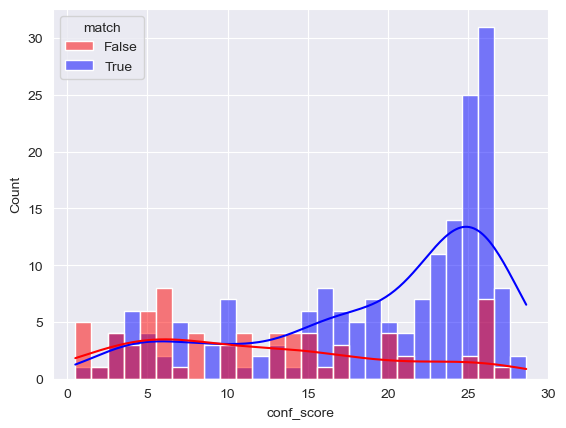

In [15]:
sns.set_style('darkgrid')
palette = {True: 'blue', False: 'red'}
sns.histplot(data=ensembled_df, x='conf_score', hue='match', alpha=0.5,binwidth=1, kde=True, palette=palette)
plt.savefig('total_distribution.png')

# Part 5: Confidence Classification

In [16]:
# separate high and low confidence values
# dependencies: os, pandas
def confidence_classification(data, output_dir, low_confidence=0.25, high_confidence=0.75, threshold=0.5, use_percentiles=True):
    """
    Classify data into high, medium, and low confidence based on either specific scores or percentiles.

    Parameters:
        data (DataFrame): The input data containing confidence scores in 'conf_score' column.
        low_confidence (float): The lower bound for low confidence, as a score or percentile.
        high_confidence (float): The threshold for high confidence, as a score or percentile.
        threshold (float): Score threshold to define 'high_conf_df' and 'low_conf_df'.
        output_dir (str): Directory to save output CSV files.
        use_percentiles (bool): If True, interpret low_confidence and high_confidence as percentiles.
    """
    # Convert percentiles to score thresholds if needed
    if use_percentiles:
        low_confidence = data['conf_score'].quantile(low_confidence)
        high_confidence = data['conf_score'].quantile(high_confidence)
        threshold = data['conf_score'].quantile(threshold)

    # Classify confidence levels
    confidence_labels = []
    for _, row in data.iterrows():
        if row['conf_score'] >= high_confidence:
            confidence_labels.append('high')
        elif row['conf_score'] <= low_confidence:
            confidence_labels.append('low')
        else:
            confidence_labels.append('medium')
    data['conf_label'] = confidence_labels

    # Separate high and low confidence data based on the threshold
    high_conf_df = data[data['conf_score'] >= threshold]
    low_conf_df = data[data['conf_score'] < threshold]

    # Save results to CSV
    os.makedirs(output_dir, exist_ok=True)
    high_conf_df.to_csv(os.path.join(output_dir, "high_conf_scores.csv"), index=False)
    low_conf_df.to_csv(os.path.join(output_dir, "low_conf_scores.csv"), index=False)

    print("High and low confidence data saved.")
    return high_conf_df, low_conf_df

In [17]:
# Function to select n examples of each label for few-shot prompting
def few_shot_data(data, labels, label_metric, threshold=0.75, n=1):
    """
    Args:
        data (DataFrame): DataFrame containing labeled examples along with their confidence scores.
        labels (list): List of possible labels (e.g., ["for", "against", "neutral"]).
        label_metric (str): Column name in the DataFrame corresponding to the label (e.g., "Stance").
        threshold (float): Quantile threshold for few shot examples, examples chosen below threshold
        n (int): Number of top examples to retrieve for each label, based on confidence score. Default is 1.

    Returns:
        dict: A dictionary where each key is a label, and each value is a DataFrame of the top n examples 
              for that label, selected by highest confidence score.
    """
    
    few_shot_examples = {}

    # Calculate the quantile threshold for collecting few shot examples
    conf_threshold = data['conf_score'].quantile(threshold)
    
    targets = data['Target'].unique()
    
    for target in targets:
        target_df = data[data['Target'] == target]
        few_shot_examples[target] = {}
        for label in labels:
            label_df = target_df[(target_df[label_metric] == label) & (target_df['conf_score'] <= conf_threshold)]
            top_n = label_df.nlargest(n, 'conf_score')
            
            # Add the top n examples to the few_shot_examples dictionary under the current target and label
            few_shot_examples[target][label] = top_n
    
    return few_shot_examples

In [18]:
def remove_between(text, start_delim, end_delim):
    pattern = re.compile(f"{re.escape(start_delim)}.*?{re.escape(end_delim)}", re.DOTALL | re.IGNORECASE)
    return pattern.sub("", text)

In [19]:
def few_shot_by_target(few_shot_examples):
    """
    Generates a dictionary of few-shot prompting strings for each target from examples grouped by target and label.

    Args:
        few_shot_examples (dict): A nested dictionary where the top-level keys are targets,
                                  the second-level keys are labels, and the values are DataFrames
                                  of examples for those labels.

    Returns:
        dict: A dictionary where each key is a target, and the value is a string containing
              the formatted few-shot examples for that target.
    """
    few_shot_prompts = {}
    
    # Iterate over each target
    for target, label_dict in few_shot_examples.items():
        count = 1
        target_prompt = ""
        # Iterate over each label within the target
        for label, examples in label_dict.items():
            # Iterate over the examples for the current label
            for _, row in examples.iterrows():
                prompt = row['prompts']  # Extract the prompt text
                
                # Clean up the prompt if necessary
                prompt = remove_between(prompt, "\nWhich of the following", "'neutral'.")
                
                # Append the example to the target's prompt string
                target_prompt += f"Example {count}:\n{prompt}Label: {label}\n"
                count += 1  # Increment the example counter
        
        # Add the target's prompt string to the dictionary
        few_shot_prompts[target] = target_prompt
    
    return few_shot_prompts

In [20]:
high_conf_df, low_conf_df = confidence_classification(ensembled_df, os.getcwd())

High and low confidence data saved.


# Part 6: Low Confidence Reevaluation

In [21]:
few_shot_examples = few_shot_data(ensembled_df, labels, label_metric)

In [22]:
few_shot_prompts = few_shot_by_target(few_shot_examples)

In [23]:
from openai import OpenAI

def openai_adjuster(few_shot_prompts, model_name):
    """
    Adjusts prompts by interacting with the OpenAI API and updates each target's examples.

    Args:
        few_shot_prompts (dict): A dictionary where keys are targets, and values are strings of examples.
        model_name (str): The name of the model to be used for adjustment.

    Returns:
        dict: A dictionary where each target is updated with the adjusted prompts.
    """
    client = OpenAI()
    
    prompt_adjuster = """
Provide a shortened reasoning, focusing on key ideas, as to why each statement is given its corresponding label.

Format for each example:
Example: ...
Statement: ...
Label: ...
Reasoning: ...

Statements:

"""
    
    for target, prompt in few_shot_prompts.items():
        full_prompt = prompt_adjuster + prompt
        
        response = client.chat.completions.create(
            model=model_name,
            messages=[
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": f"Target: {target}\n{full_prompt}"},
            ]
        )
        
        adjusted_prompt = response.choices[0].message.content
        few_shot_prompts[target] = adjusted_prompt
    
    return few_shot_prompts

In [24]:
adjusted_prompts = openai_adjuster(few_shot_prompts, "gpt-4o-mini")
for target, prompt in adjusted_prompts.items():
    print(f"\nTarget: {target}")
    print(prompt)


Target: Feminist Movement
Example 1:
Statement: @fxckyoustagram u have no reason to need feminism in the 1st world.u are equal. Stop trying to make a case for victimhood. #SemST  
Label: against  
Reasoning: The statement dismisses the need for feminism in developed countries, questioning the notion of victimhood. It implies that equality has already been achieved, which undermines feminist arguments advocating for continued efforts toward equality.

Example 2:
Statement: @Piddy_X @Nero @CYBERSTALIN It's an attempt at a @GodfreyElfwick parody. #ProteinWorld #BaltimoreRiots #socialism #SemST  
Label: neutral  
Reasoning: This statement does not express a clear opinion on feminism; rather, it comments on a specific parody without engaging directly in feminist discourse. Thus, it is neither supportive nor opposed to the feminist movement.

Example 3:
Statement: By writing her self, woman will return to the body which has been more than confiscated from her - Hélène Cixous #theatre #SemST

# Part 7: Re-Labeling

In [25]:
reeval_df = low_conf_df.copy()
reeval_df.head()

,Unnamed: 0,ID,Target,Tweet,Stance,Opinion towards,Sentiment,prompts,label_logprobs,pred_label,raw_pred_label,conf_score,link,link_0_label,link_0_conf_score,link_0_conf_rank,backward_label_link_src,backward_label,match,conf_label
3083,1834,1935,Hillary Clinton,@PolitiBunny @Seja75 @hubbit @HillaryClinton I...,against,TARGET,POSITIVE,Statement: @PolitiBunny @Seja75 @hubbit @Hilla...,"[-13.131820678710938, -5.0068206787109375, -0....",neutral,neutral,5.000,0,neutral,5.000,0.112,0,neutral,False,low
3326,2077,2178,Hillary Clinton,Obama give Americans OVERTIME Pay! Republicans...,against,OTHER,NEGATIVE,Statement: Obama give Americans OVERTIME Pay! ...,"[-22.375810623168945, -11.500810623168945, -0....",neutral,neutral,11.500,0,neutral,11.500,0.292,0,neutral,False,medium
3318,2069,2170,Hillary Clinton,#AskPOTUS Would you fire the #GOP congress for...,against,OTHER,NEGATIVE,Statement: #AskPOTUS Would you fire the #GOP c...,"[-24.8750057220459, -15.000005722045898, -6.15...",neutral,neutral,15.000,0,neutral,15.000,0.356,0,neutral,False,medium
4113,50,51,Legalization of Abortion,Just laid down the law on abortion in my bioet...,against,TARGET,NEGATIVE,Statement: Just laid down the law on abortion ...,"[-19.000455856323242, -0.0004556983185466379, ...",against,against,9.625,0,against,9.625,0.236,0,against,True,low
2899,1650,1751,Hillary Clinton,@bristola48 @AlciniaH @Mahogany1992 @stphil @M...,neutral,NO ONE,NEGATIVE,Statement: @bristola48 @AlciniaH @Mahogany1992...,"[-20.90483283996582, -3.529832124710083, -0.02...",neutral,neutral,3.500,0,neutral,3.500,0.064,0,neutral,True,low


In [26]:
label_dataset(dataset_name="SemEval2016", model_name="gpt-4o-mini", output_dir="./chain_out", sample_size=-1, CoT=False,
             data=reeval_df, prompt_mod=adjusted_prompts)

100%|██████████| 125/125 [00:37<00:00,  3.32it/s]

Labeling complete. Results saved to ./chain_out\results_df.pkl, metadata saved to ./chain_out\meta.json.


In [27]:
# path specifically for this test
re_gpt_link = pd.read_pickle("./chain_out/results_df.pkl")

links = [re_gpt_link]
names = ["gpt"]

In [28]:
re_chained_df, re_chained_meta_data = chain_dataframes(links, "Stance")
re_ensembled_df = backward_pass(re_chained_df, len(links))

In [29]:
re_ensembled_df['match'] = re_ensembled_df['Stance'] == re_ensembled_df['link_0_label']

# Results

In [30]:
re_chained_meta_data

{'link_0_full_acc': 0.632,
 'link_0_full_f1': 0.6348989816970113,
 'link_0_threshold': 0.5,
 'link_0_retained_acc': 0.632,
 'link_0_retained_f1': 0.6348989816970113,
 'link_0_retained_size': 125,
 'total_acc': 0.632,
 'total_f1': 0.6348989816970113}

In [31]:
percentage_true = (re_ensembled_df['match'].sum() / len(re_ensembled_df)) * 100
print(f"Re-Labeled Accuracy: {percentage_true}%")

Re-Labeled Accuracy: 63.2%


In [32]:
labels = re_ensembled_df['Stance'].unique()

for label in labels:
    lab_acc_df = re_ensembled_df[re_ensembled_df['Stance'] == label]
    lab_acc = round(accuracy_score(lab_acc_df['pred_label'], lab_acc_df['Stance']), 3)
    print(f'{label} accuracy:', lab_acc)

against accuracy: 0.582
neutral accuracy: 0.735
for accuracy: 0.611


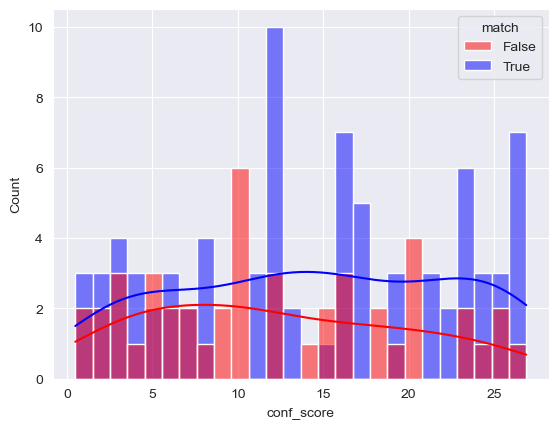

In [33]:
palette = {True: 'blue', False: 'red'}
sns.histplot(data=re_ensembled_df, x='conf_score', hue='match', alpha=0.5,binwidth=1, kde=True, palette=palette)
plt.savefig('re_labeled_low_conf_distribution.png')

In [34]:
percentage_true = (low_conf_df['match'].sum() / len(low_conf_df)) * 100
print(f"Initial Labeled Accuracy: {percentage_true}%")

Initial Labeled Accuracy: 56.00000000000001%


In [35]:
labels = low_conf_df['Stance'].unique()

for label in labels:
    lab_acc_df = low_conf_df[low_conf_df['Stance'] == label]
    lab_acc = round(accuracy_score(lab_acc_df['pred_label'], lab_acc_df['Stance']), 3)
    print(f'{label} accuracy:', lab_acc)

against accuracy: 0.618
neutral accuracy: 0.441
for accuracy: 0.583


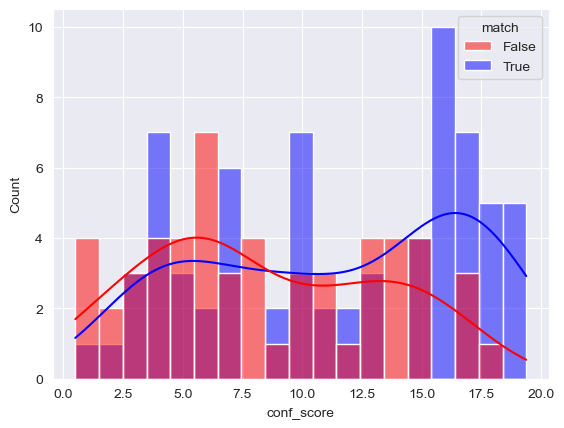

In [36]:
sns.histplot(data=low_conf_df, x='conf_score', hue='match', alpha=0.5, binwidth=1, kde=True, palette=palette)
plt.savefig('low_conf_distribution.png')